# Benedictus Irvanda Nugroho
## Mini Assignment

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

## 1. Data Understanding

In [35]:
df = pd.read_csv(r'Customer Satisfaction and Sentiment Analysis.csv')
df.head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2,1,1,2,1,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2,3,2,2,2,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4,4,5,5,5,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2,2,4,3,3,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3,4,2,3,3,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         100000 non-null  int64  
 1   id                                 100000 non-null  int64  
 2   Gender                             100000 non-null  str    
 3   Customer Type                      100000 non-null  str    
 4   Age                                100000 non-null  int64  
 5   Type of Travel                     100000 non-null  str    
 6   Class                              100000 non-null  str    
 7   Flight Distance                    100000 non-null  int64  
 8   Inflight wifi service              100000 non-null  int64  
 9   Departure/Arrival time convenient  100000 non-null  int64  
 10  Ease of Online booking             100000 non-null  int64  
 11  Gate location                      100000 non-null 

In [37]:
df[df['Arrival Delay in Minutes'].isnull()]

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
213,213,49608,Female,Loyal Customer,38,Business travel,Eco,109,5,3,3,3,5,5,5,5,5,2,4,1,1,5,31,NaN,satisfied
1124,1124,73442,Male,Loyal Customer,53,Personal Travel,Eco,1012,3,2,3,4,4,3,4,4,4,4,4,3,3,4,38,NaN,neutral or dissatisfied
1529,1529,71178,Male,Loyal Customer,39,Business travel,Business,733,2,5,5,5,2,4,3,2,2,2,2,2,2,3,11,NaN,neutral or dissatisfied
2004,2004,72940,Female,disloyal Customer,26,Business travel,Business,1035,3,3,3,1,2,3,2,2,3,3,4,5,5,2,41,NaN,neutral or dissatisfied
2108,2108,116374,Female,Loyal Customer,24,Personal Travel,Eco,417,2,1,2,2,5,2,5,5,1,4,2,1,2,5,1,NaN,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97915,97915,20070,Male,Loyal Customer,66,Personal Travel,Eco,607,4,4,3,3,5,3,5,5,5,5,4,5,5,5,20,NaN,neutral or dissatisfied
98446,98446,20953,Female,Loyal Customer,45,Business travel,Eco,689,3,5,5,5,1,4,5,3,3,3,3,3,3,3,0,NaN,satisfied
98636,98636,7116,Male,Loyal Customer,54,Personal Travel,Eco,157,2,4,2,2,2,2,2,2,3,4,4,3,4,2,0,NaN,neutral or dissatisfied
98946,98946,19609,Male,Loyal Customer,65,Business travel,Business,3663,3,3,3,3,2,4,3,4,4,4,4,5,4,5,1,NaN,satisfied


In [38]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.00000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,99700.000000
mean,49999.500000,64925.805660,39.379330,1190.58611,2.728820,3.059130,2.75604,2.97566,3.203310,3.250760,3.440340,3.358180,3.382230,3.350560,3.631930,3.303820,3.64012,3.287260,14.823680,15.185727
std,28867.657797,37453.371794,15.110524,997.24029,1.327411,1.525273,1.39810,1.27692,1.329779,1.349273,1.319325,1.333403,1.288707,1.315464,1.180749,1.265286,1.17590,1.312158,38.206983,38.677722
min,0.000000,1.000000,7.000000,31.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,24999.750000,32554.750000,27.000000,414.00000,2.000000,2.000000,2.00000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.00000,2.000000,0.000000,0.000000
50%,49999.500000,64883.500000,40.000000,844.00000,3.000000,3.000000,3.00000,3.00000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.00000,3.000000,0.000000,0.000000
75%,74999.250000,97346.250000,51.000000,1744.00000,4.000000,4.000000,4.00000,4.00000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.00000,4.000000,12.000000,13.000000
max,99999.000000,129880.000000,85.000000,4983.00000,5.000000,5.000000,5.00000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,1592.000000,1584.000000


In [64]:
df['Arrival Delay in Minutes'].describe()

count    99700.000000
mean        15.185727
std         38.677722
min          0.000000
25%          0.000000
50%          0.000000
75%         13.000000
max       1584.000000
Name: Arrival Delay in Minutes, dtype: float64

In [39]:
df.shape

(100000, 25)

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.describe(include=["object"])

C:\Users\Irvan N\AppData\Local\Temp\ipykernel_21344\3753758486.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object"])


,Gender,Customer Type,Type of Travel,Class,satisfaction
count,100000,100000,100000,100000,100000
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,50714,81713,68977,47806,56665


In [42]:
# persentase missing values tiap kolom
(df.isnull().sum() / len(df)) * 100

Unnamed: 0                           0.0
id                                   0.0
Gender                               0.0
Customer Type                        0.0
Age                                  0.0
Type of Travel                       0.0
Class                                0.0
Flight Distance                      0.0
Inflight wifi service                0.0
Departure/Arrival time convenient    0.0
Ease of Online booking               0.0
Gate location                        0.0
Food and drink                       0.0
Online boarding                      0.0
Seat comfort                         0.0
Inflight entertainment               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                     0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                          0.0
Departure Delay in Minutes           0.0
Arrival Delay in Minutes             0.3
satisfaction    

In [43]:
# Mengambil kolom kategorikal
cat_col = df.select_dtypes(include=['object']).columns

cat_info = []

for col in cat_col:
    cat_info.append({
        'column_name': col,
        'n_unique': df[col].nunique(),
        'sample_unique_values': df[col].dropna().unique()[:10].tolist()
    })

# Membuat dataframe
df_cat_info = pd.DataFrame(cat_info)

# Menampilkan
df_cat_info

C:\Users\Irvan N\AppData\Local\Temp\ipykernel_21344\3592911707.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=['object']).columns


,column_name,n_unique,sample_unique_values
0,Gender,2,"[Male, Female]"
1,Customer Type,2,"[Loyal Customer, disloyal Customer]"
2,Type of Travel,2,"[Personal Travel, Business travel]"
3,Class,3,"[Eco Plus, Business, Eco]"
4,satisfaction,2,"[neutral or dissatisfied, satisfied]"


In [44]:
print("===VALUE COUNTS UNTUK KOLOM KATEGORIKAL ===")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'Date':  # Lewati kolom tanggal agar output tidak terlalu panjang
        print(f"\nValue Counts untuk kolom '{col}':")
        print(df[col].value_counts())
        print("-" * 40)

===VALUE COUNTS UNTUK KOLOM KATEGORIKAL ===

Value Counts untuk kolom 'Gender':
Gender
Female    50714
Male      49286
Name: count, dtype: int64
----------------------------------------

Value Counts untuk kolom 'Customer Type':
Customer Type
Loyal Customer       81713
disloyal Customer    18287
Name: count, dtype: int64
----------------------------------------

Value Counts untuk kolom 'Type of Travel':
Type of Travel
Business travel    68977
Personal Travel    31023
Name: count, dtype: int64
----------------------------------------

Value Counts untuk kolom 'Class':
Class
Business    47806
Eco         44998
Eco Plus     7196
Name: count, dtype: int64
----------------------------------------

Value Counts untuk kolom 'satisfaction':
satisfaction
neutral or dissatisfied    56665
satisfied                  43335
Name: count, dtype: int64
----------------------------------------


C:\Users\Irvan N\AppData\Local\Temp\ipykernel_21344\1782128935.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [45]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n===== {col} =====")
    print(df[col].unique())


===== Gender =====
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

===== Customer Type =====
<ArrowStringArray>
['Loyal Customer', 'disloyal Customer']
Length: 2, dtype: str

===== Type of Travel =====
<ArrowStringArray>
['Personal Travel', 'Business travel']
Length: 2, dtype: str

===== Class =====
<ArrowStringArray>
['Eco Plus', 'Business', 'Eco']
Length: 3, dtype: str

===== satisfaction =====
<ArrowStringArray>
['neutral or dissatisfied', 'satisfied']
Length: 2, dtype: str


C:\Users\Irvan N\AppData\Local\Temp\ipykernel_21344\1774054245.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


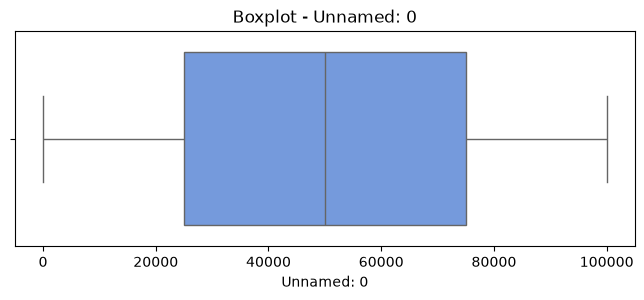

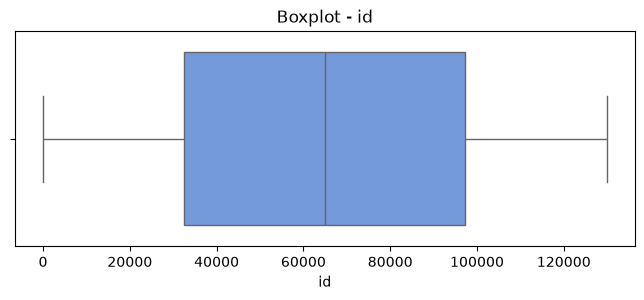

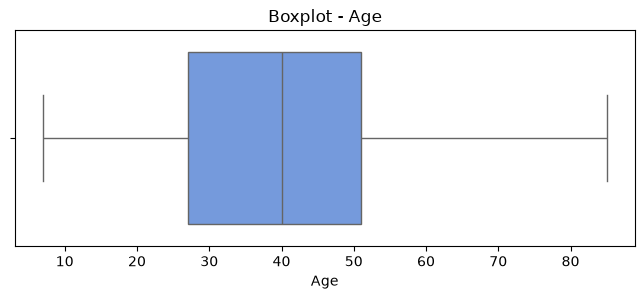

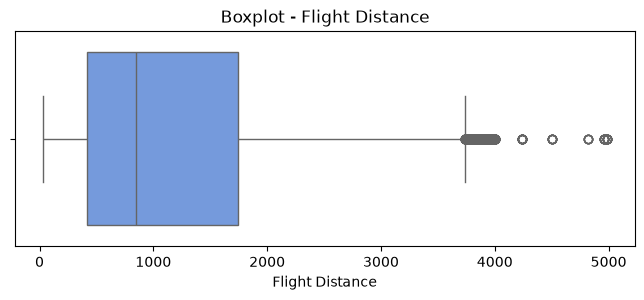

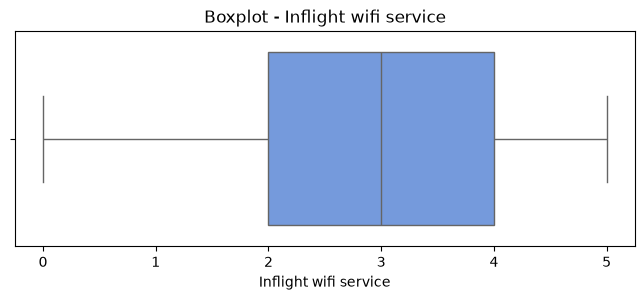

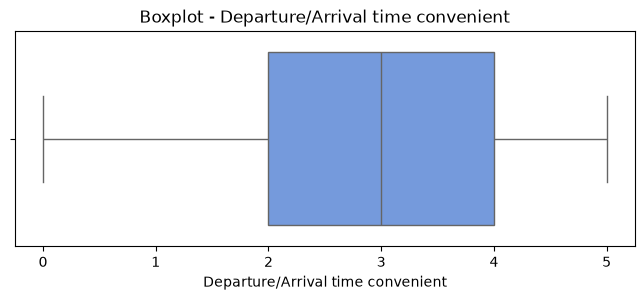

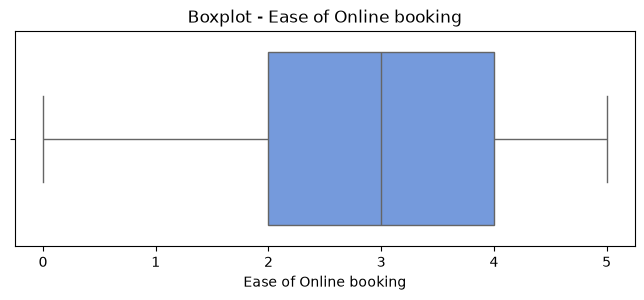

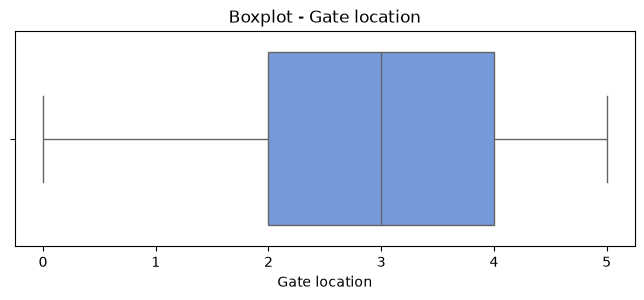

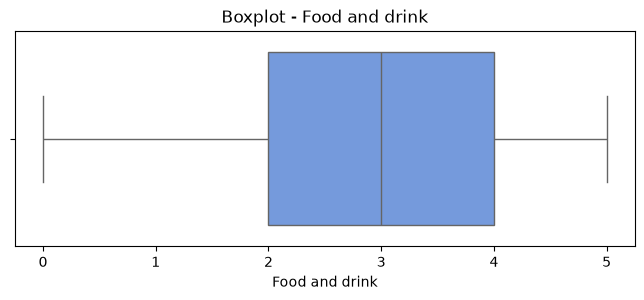

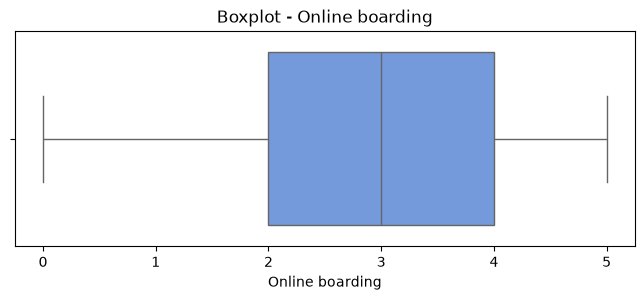

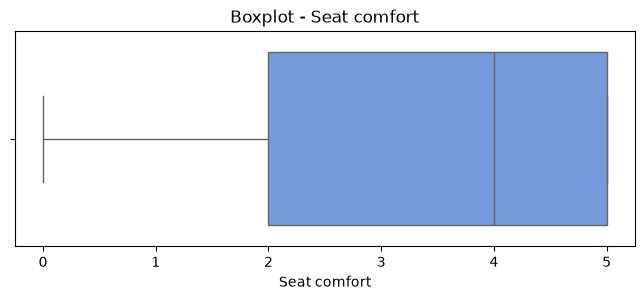

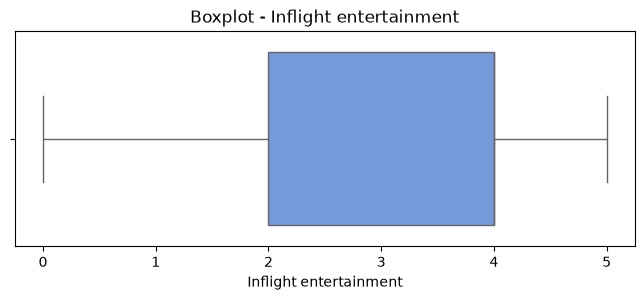

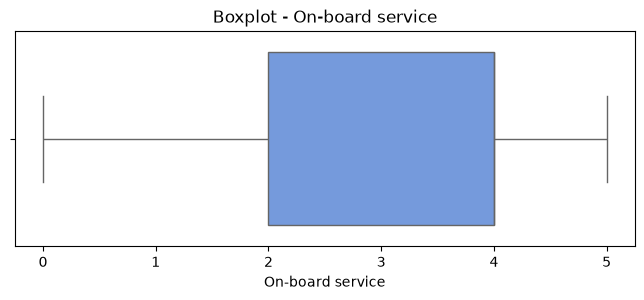

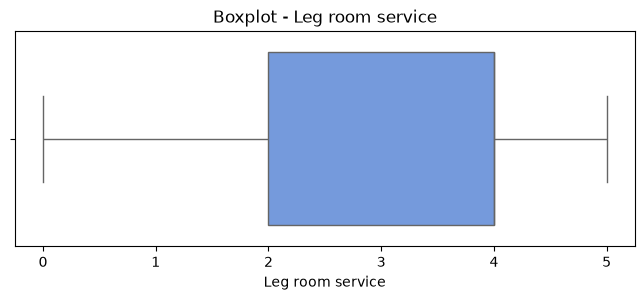

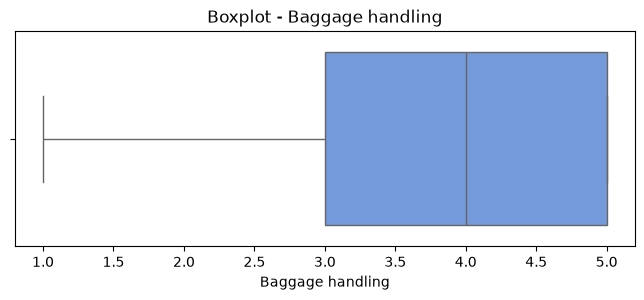

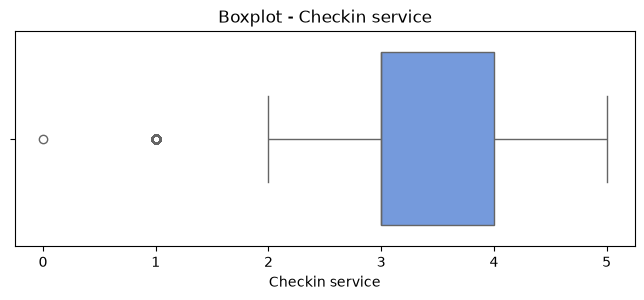

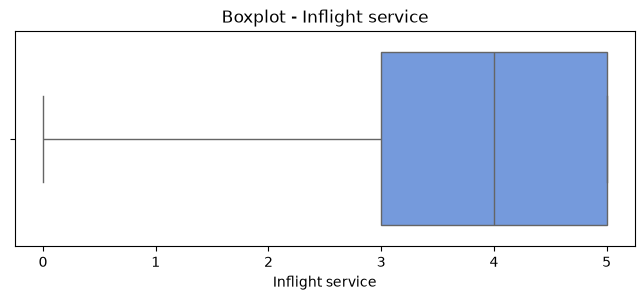

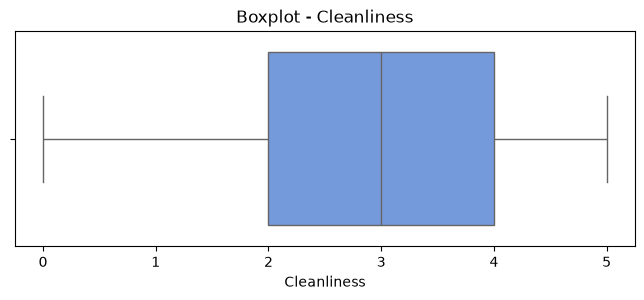

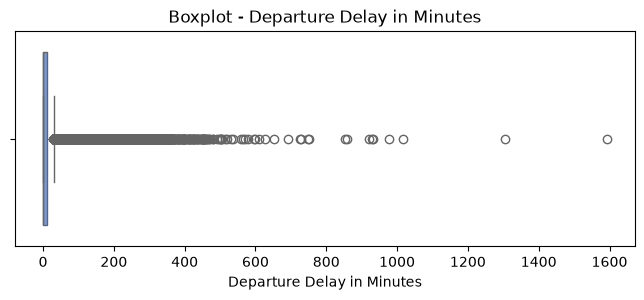

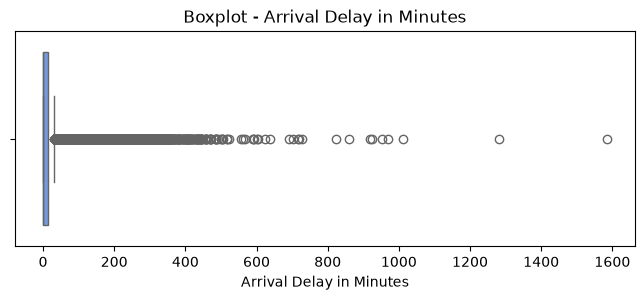

In [46]:
# Visualisasi Boxplot per Kolom Numerik

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(8, 2.8))
    sns.boxplot(x=df[col], color='cornflowerblue')
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

In [47]:
print("\n=== DETEKSI OUTLIER MENGGUNAKAN METODE IQR ===")

# Kolom continuous yang relevan untuk outlier detection
# (Rating 1-5 tidak perlu dicek outlier karena bounded)
num_cols = [
    'Age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes'
]

outlier_indices = set()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_indices.update(outliers.index.tolist())
    
    print(f"Kolom {col:30}: {len(outliers):5} outliers "
          f"(Batas: {lower_bound:.1f} s/d {upper_bound:.1f})")

print(f"\nTotal baris dengan minimal 1 outlier: {len(outlier_indices)}")
print(f"Persentase dari dataset         : {len(outlier_indices)/len(df)*100:.2f}%")


=== DETEKSI OUTLIER MENGGUNAKAN METODE IQR ===
Kolom Age                           :     0 outliers (Batas: -9.0 s/d 87.0)
Kolom Flight Distance               :  2185 outliers (Batas: -1581.0 s/d 3739.0)
Kolom Departure Delay in Minutes    : 14019 outliers (Batas: -18.0 s/d 30.0)
Kolom Arrival Delay in Minutes      : 13470 outliers (Batas: -19.5 s/d 32.5)

Total baris dengan minimal 1 outlier: 17873
Persentase dari dataset         : 17.87%


## 2. Data Preprocessing

In [48]:
# Drop 300 baris dengan Arrival Delay null (hanya 0.3% dari data)
df.dropna(subset=['Arrival Delay in Minutes'], inplace=True)
print(f"\nShape setelah drop missing values: {df.shape}")


Shape setelah drop missing values: (99700, 25)


In [49]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].astype(int)

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 99700 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Unnamed: 0                         99700 non-null  int64
 1   id                                 99700 non-null  int64
 2   Gender                             99700 non-null  str  
 3   Customer Type                      99700 non-null  str  
 4   Age                                99700 non-null  int64
 5   Type of Travel                     99700 non-null  str  
 6   Class                              99700 non-null  str  
 7   Flight Distance                    99700 non-null  int64
 8   Inflight wifi service              99700 non-null  int64
 9   Departure/Arrival time convenient  99700 non-null  int64
 10  Ease of Online booking             99700 non-null  int64
 11  Gate location                      99700 non-null  int64
 12  Food and drink                    

In [51]:
df.drop('Unnamed: 0', axis=1, inplace=True)

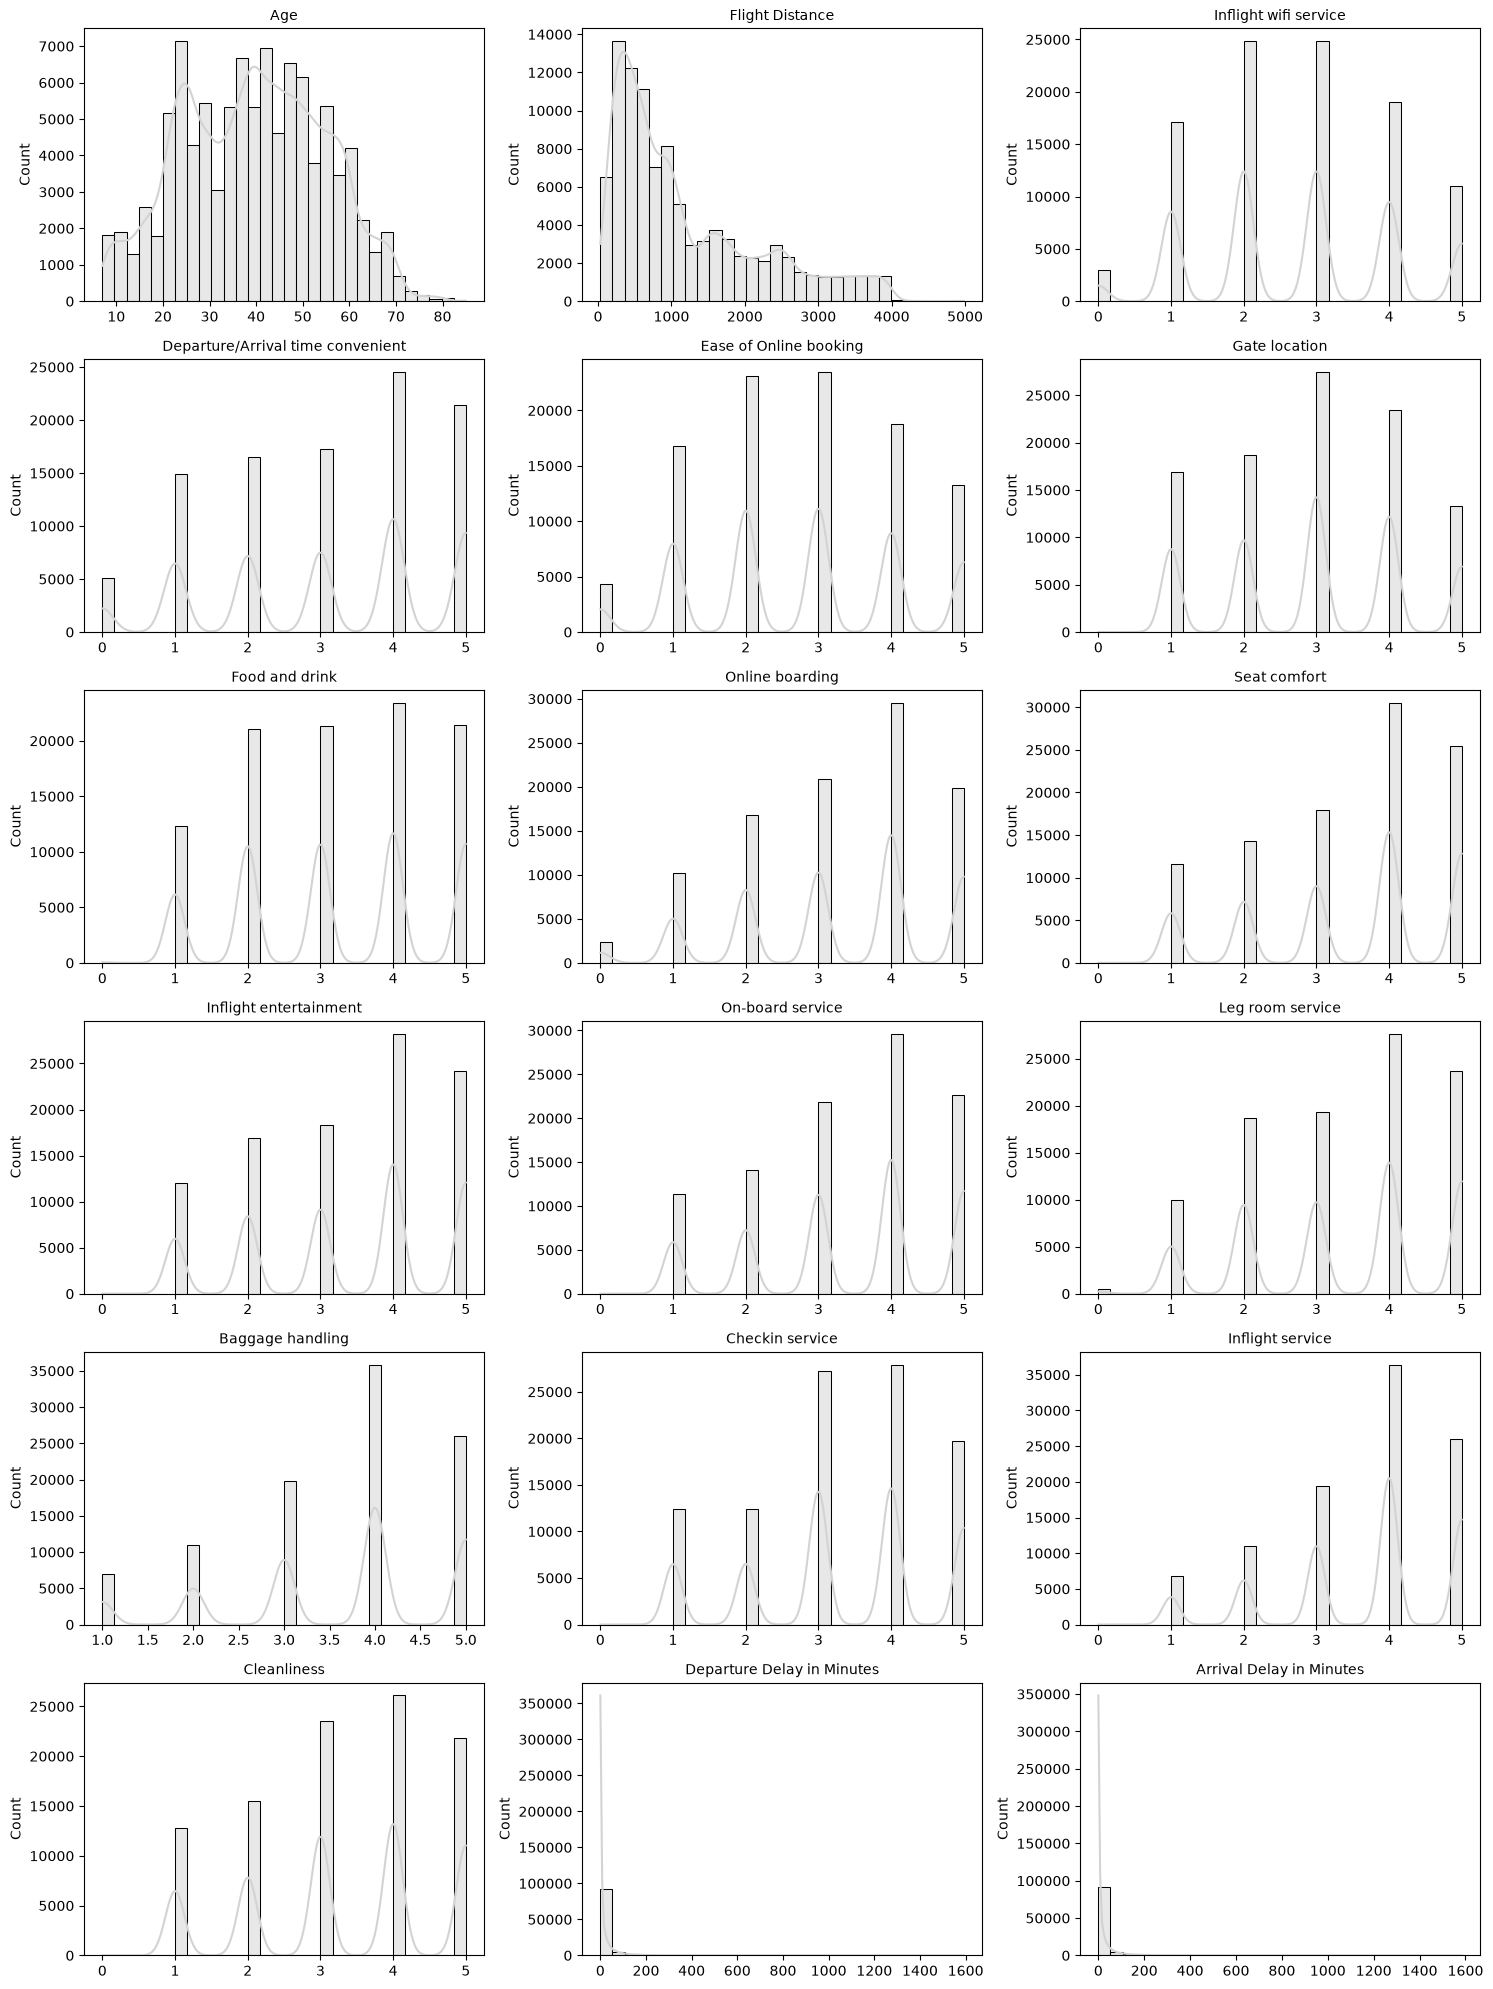

In [52]:
# Kolom numerik
num_cols = [
    'Age', 'Flight Distance',
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness',
    'Departure Delay in Minutes', 'Arrival Delay in Minutes'
]

# Membuat grid plot
fig, axes = plt.subplots(6, 3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color="lightgray",
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Menghapus subplot kosong
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [53]:
import scipy
from scipy.stats import normaltest
# Kolom yang akan diuji
continuous_cols = [
    'Age', 'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes'
]

rating_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

test_cols = continuous_cols + rating_cols

results = []

for col in test_cols:
    statistic, p_value = normaltest(df[col].dropna())

    results.append({
        "Column": col,
        "Statistic": round(statistic, 2),
        "P-Value": f"{p_value:.5f}" if p_value >= 0.00001 else "<0.00001",
        "Skewness": round(df[col].skew(), 3),
        "Normal Distribution": "Yes" if p_value > 0.05 else "No"
    })

normality_df = pd.DataFrame(results)

display(normality_df)

,Column,Statistic,P-Value,Skewness,Normal Distribution
0,Age,5753.56,<0.00001,-0.003,No
1,Flight Distance,13936.35,<0.00001,1.108,No
2,Departure Delay in Minutes,127100.21,<0.00001,6.813,No
3,Arrival Delay in Minutes,124951.23,<0.00001,6.640,No
4,Inflight wifi service,10525.26,<0.00001,0.040,No
5,Departure/Arrival time convenient,29978.36,<0.00001,-0.334,No
6,Ease of Online booking,14336.61,<0.00001,-0.018,No
7,Gate location,27007.85,<0.00001,-0.059,No
8,Food and drink,57124.39,<0.00001,-0.153,No
9,Online boarding,8432.37,<0.00001,-0.454,No


D'Agostino-Pearson Normality Test

Hypothesis

H₀: Data mengikuti distribusi normal.
H₁: Data tidak mengikuti distribusi normal.

Decision Rule

Jika p-value ≤ 0.05, tolak H₀ → data tidak berdistribusi normal.

In [54]:
df.head(3)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0,satisfied


In [55]:
df_corr = df.copy()

# Binary encoding langsung (2 kategori)
df_corr['Gender']        = df_corr['Gender'].map({'Male': 1, 'Female': 0})
df_corr['Customer Type'] = df_corr['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})
df_corr['Type of Travel']= df_corr['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0})
df_corr['satisfaction']  = df_corr['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

# Label encoding untuk Class (ordinal: Eco=0, Eco Plus=1, Business=2)
df_corr['Class'] = df_corr['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})

# Drop kolom id (bukan variabel analitis)
df_corr.drop(columns=['id'], inplace=True)

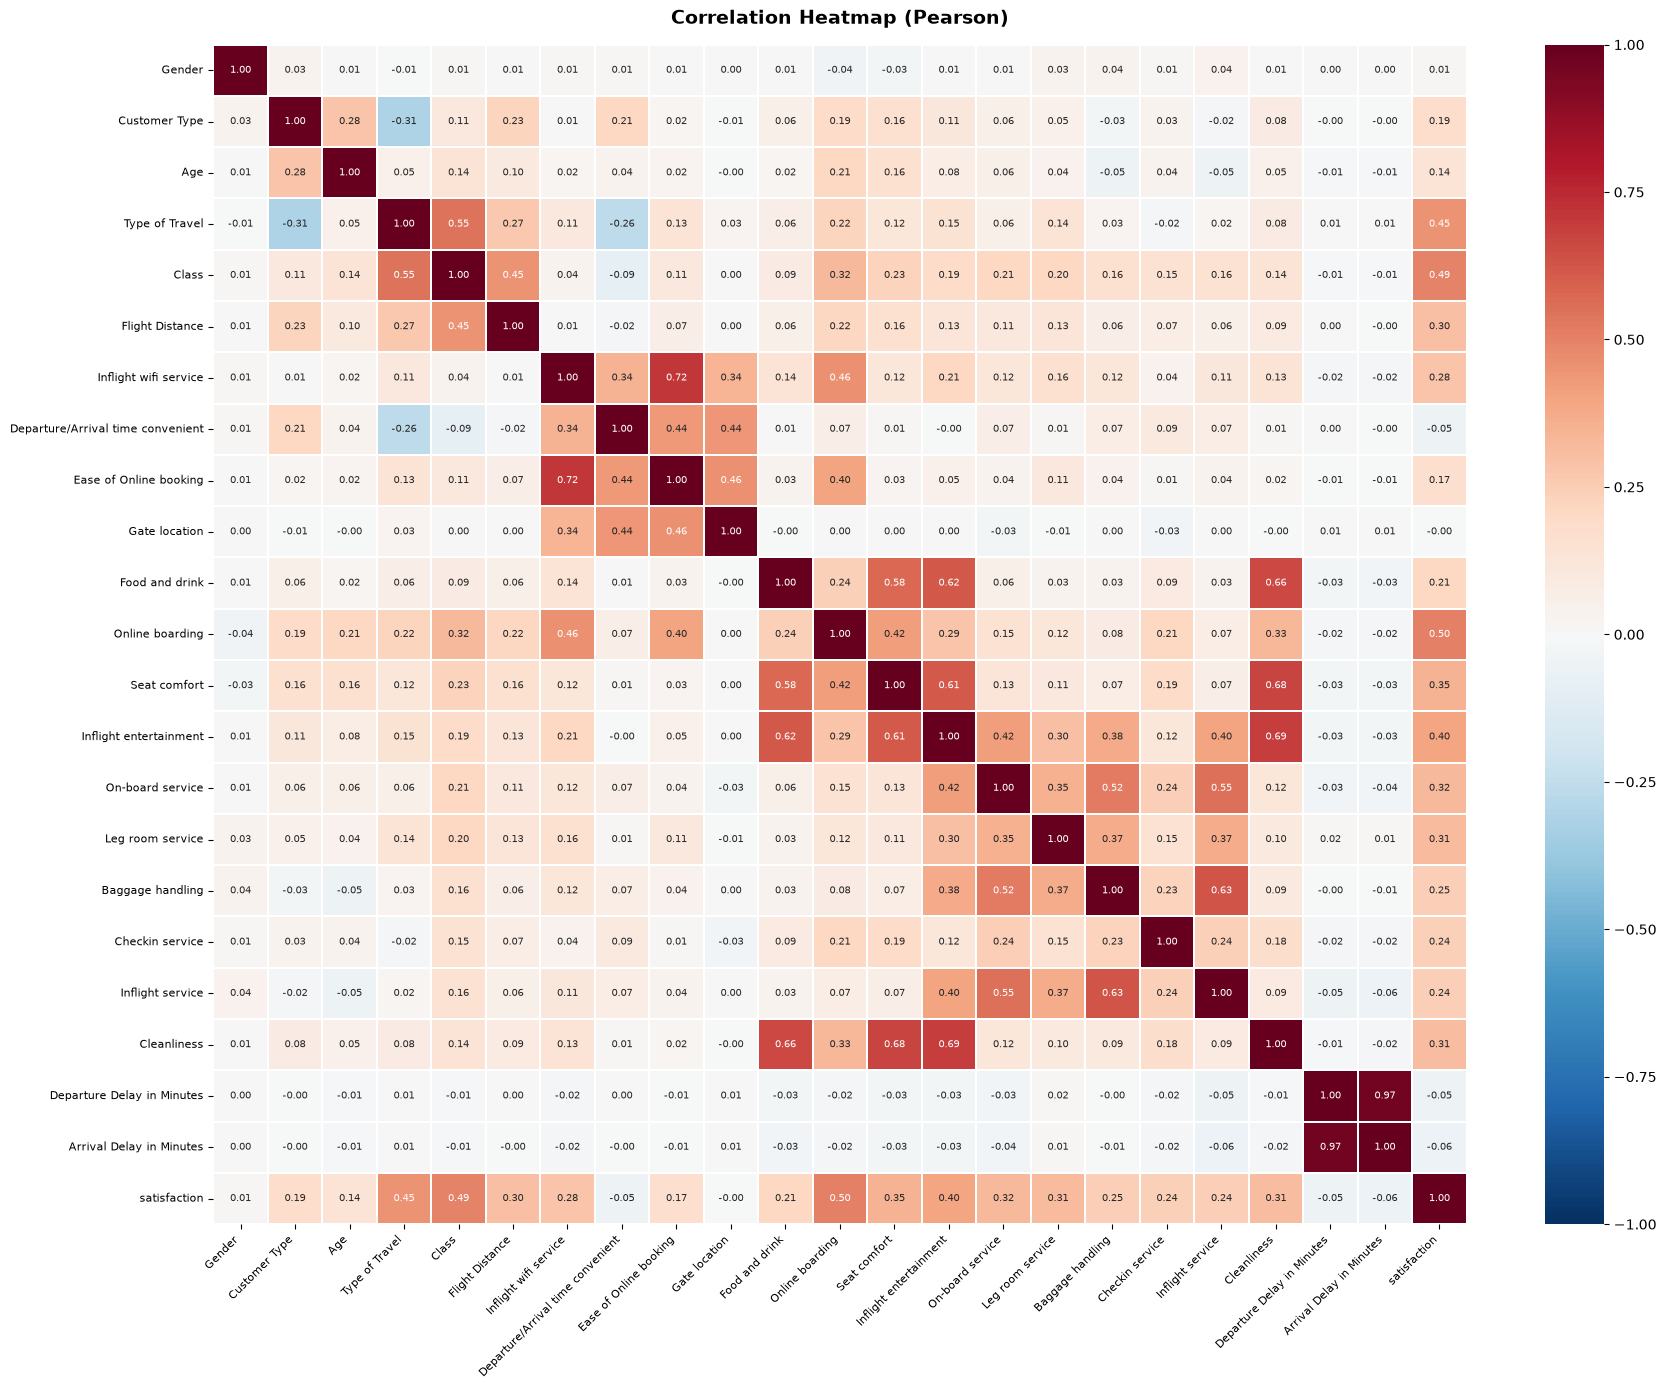

In [56]:
corr_matrix = df_corr.corr(method='pearson')

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot_kws={'size': 7},
    linewidths=0.3
)

plt.title('Correlation Heatmap (Pearson)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
sat_corr = corr_matrix['satisfaction'].drop('satisfaction').sort_values(ascending=False)

print("=== Korelasi Terhadap Satisfaction (descending) ===\n")
for col, val in sat_corr.items():
    bar = '█' * int(abs(val) * 20)
    arah = '+' if val >= 0 else '-'
    print(f"{col:35} [{arah}] {val:+.3f}  {bar}")

=== Korelasi Terhadap Satisfaction (descending) ===

Online boarding                     [+] +0.504  ██████████
Class                               [+] +0.495  █████████
Type of Travel                      [+] +0.449  ████████
Inflight entertainment              [+] +0.398  ███████
Seat comfort                        [+] +0.349  ██████
On-board service                    [+] +0.321  ██████
Leg room service                    [+] +0.313  ██████
Cleanliness                         [+] +0.305  ██████
Flight Distance                     [+] +0.299  █████
Inflight wifi service               [+] +0.284  █████
Baggage handling                    [+] +0.246  ████
Inflight service                    [+] +0.244  ████
Checkin service                     [+] +0.236  ████
Food and drink                      [+] +0.210  ████
Customer Type                       [+] +0.187  ███
Ease of Online booking              [+] +0.171  ███
Age                                 [+] +0.136  ██
Gender                

In [58]:
service_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

df["Service Score"] = df[service_cols].mean(axis=1)

df["Delay Category"] = pd.cut(
    df["Arrival Delay in Minutes"],
    bins=[-1,0,15,60,10000],
    labels=[
        "No Delay",
        "Minor Delay",
        "Major Delay",
        "Severe Delay"
    ]
)

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0,18,30,45,60,100],
    labels=[
        "Teen",
        "Young Adult",
        "Adult",
        "Senior",
        "Elder"
    ]
)

df["Flight Distance Category"] = pd.cut(
    df["Flight Distance"],
    bins=[0, 500, 1000, 2000, 5000],
    labels=["Short (<500km)", "Medium (500-1000km)", "Long (1000-2000km)", "Very Long (>2000km)"]
)

df["Is Delayed"] = (df["Arrival Delay in Minutes"] > 0).astype(int)

df["Service Score Category"] = pd.cut(
    df["Service Score"],
    bins=[0, 2, 3, 4, 5],
    labels=["Poor (1-2)", "Fair (2-3)", "Good (3-4)", "Excellent (4-5)"]
)

df["Satisfaction Binary"] = (df["satisfaction"] == "satisfied").astype(int) 

## 3. Exploratory Data Analysis (EDA)

In [59]:
df.head(3)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Service Score,Delay Category,Age Group,Flight Distance Category,Is Delayed,Service Score Category,Satisfaction Binary
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18,neutral or dissatisfied,3.857143,Major Delay,Teen,Short (<500km),1,Good (3-4),0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6,neutral or dissatisfied,2.285714,Minor Delay,Young Adult,Short (<500km),1,Fair (2-3),0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0,satisfied,3.714286,No Delay,Young Adult,Long (1000-2000km),0,Good (3-4),1


In [60]:
pd.set_option('display.max_columns', None)
df.head(3)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Service Score,Delay Category,Age Group,Flight Distance Category,Is Delayed,Service Score Category,Satisfaction Binary
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18,neutral or dissatisfied,3.857143,Major Delay,Teen,Short (<500km),1,Good (3-4),0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6,neutral or dissatisfied,2.285714,Minor Delay,Young Adult,Short (<500km),1,Fair (2-3),0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0,satisfied,3.714286,No Delay,Young Adult,Long (1000-2000km),0,Good (3-4),1


In [61]:
df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Service Score,Is Delayed,Satisfaction Binary
count,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000,99700.000000
mean,64943.910110,39.380522,1190.446871,2.728917,3.058887,2.756108,2.975777,3.203360,3.250903,3.440762,3.358415,3.382427,3.350913,3.631795,3.303892,3.640461,3.287372,14.756830,15.185727,3.240714,0.438977,0.433400
std,37449.181759,15.108552,997.377015,1.327437,1.525437,1.398098,1.277033,1.329669,1.349165,1.319094,1.333430,1.288645,1.315293,1.180902,1.265277,1.175832,1.312066,38.095515,38.677722,0.661807,0.496265,0.495547
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.071429,0.000000,0.000000
25%,32579.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,2.785714,0.000000,0.000000
50%,64917.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,3.285714,0.000000,0.000000
75%,97346.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,3.714286,1.000000,1.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000,5.000000,1.000000,1.000000


In [63]:
df['Arrival Delay in Minutes'].describe()

count    99700.000000
mean        15.185727
std         38.677722
min          0.000000
25%          0.000000
50%          0.000000
75%         13.000000
max       1584.000000
Name: Arrival Delay in Minutes, dtype: float64

In [62]:
df.to_csv(
    "customer_satisfaction_clean.csv",
    index=False
)